# Notebook 05 — Machine Learning
**Project:** Huawei Telecom Complaint Analytics & Network Intelligence Platform  
**Deliverable:** D4 — ML Models  

---
## Table of Contents
1. Setup & Chargement
2. Anomaly Detection (Isolation Forest + Z-score)
3. Spike Prediction (ARIMA + Prophet + XGBoost)
4. Root Cause Classification (Random Forest + XGBoost + SHAP)
5. Customer Clustering (K-Means + DBSCAN)
6. Synthèse — D4


## 1. Setup & Chargement

In [1]:
import sys, os
PROJECT_ROOT = r'C:\Users\c50057188\Desktop\PFE_Ouerghi'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')
COLORS  = sns.color_palette('husl', 10)
FIGURES = 'reports/figures'
os.makedirs(FIGURES, exist_ok=True)
print('Setup ✓')

Setup ✓


In [2]:
# Charger les datasets traités
feature_matrix  = pd.read_parquet('data/processed/feature_matrix.parquet')
complaint_agg   = pd.read_parquet('data/processed/complaint_daily_agg.parquet')
kpi_agg         = pd.read_parquet('data/processed/kpi_daily_agg.parquet')
complaints_clean= pd.read_parquet('data/processed/complaints_clean.parquet')
kpi_clean       = pd.read_parquet('data/processed/kpi_clean.parquet')

from src.processing.feature_engineering import time_series_split
X_train, X_test, y_train, y_test = time_series_split(feature_matrix)

print(f'feature_matrix  : {feature_matrix.shape}')
print(f'X_train/X_test  : {X_train.shape} / {X_test.shape}')
print(f'y_train range   : {y_train.min():.0f} – {y_train.max():.0f}  mean={y_train.mean():.1f}')
print(f'Spike days      : {int(feature_matrix["complaint_spike_flag"].sum())} '
      f'({feature_matrix["complaint_spike_flag"].mean()*100:.1f}%)')

2026-04-28 01:43:13.517 | INFO     | src.processing.feature_engineering:time_series_split:533 -   Train/test split: 6,470 train | 1,618 test | 158 features


feature_matrix  : (8088, 168)
X_train/X_test  : (6470, 158) / (1618, 158)
y_train range   : 0 – 120  mean=2.9
Spike days      : 306 (3.8%)


## 2. Anomaly Detection
**Modèles :** Isolation Forest (multivariée) + Z-score/CUSUM (série temporelle)  
**Objectif :** Détecter les dégradations KPI anormales qui précèdent les pics de plaintes


In [3]:
from src.models.anomaly_detector import AnomalyDetector

detector = AnomalyDetector()
ad_results = detector.run(kpi_agg)

2026-04-28 01:43:17.292 | INFO     | src.models.anomaly_detector:run:91 - =======================================================
2026-04-28 01:43:17.295 | INFO     | src.models.anomaly_detector:run:92 - ANOMALY DETECTION
2026-04-28 01:43:17.297 | INFO     | src.models.anomaly_detector:run:93 - =======================================================
2026-04-28 01:43:17.297 | INFO     | src.models.anomaly_detector:run:96 - 
[1/3] Training Isolation Forest ...
2026-04-28 01:43:18.538 | INFO     | src.models.anomaly_detector:_run_isolation_forest:165 -   IF: 207 anomalies detected (2.6% of records)
2026-04-28 01:43:18.542 | INFO     | src.models.anomaly_detector:run:100 - 
[2/3] Running statistical control charts ...
2026-04-28 01:43:18.894 | INFO     | src.models.anomaly_detector:_run_statistical:221 -   Statistical: 945 anomalies detected (11.7% of records)
2026-04-28 01:43:18.896 | INFO     | src.models.anomaly_detector:run:104 - 
[3/3] Combining results ...
2026-04-28 01:43:19.070 | I

In [4]:
if_df = ad_results['isolation_forest']
st_df = ad_results['statistical']
cb_df = ad_results['combined']
m     = ad_results['metrics']

total = m.get('total_records', 1)
n_if  = m.get('if_anomalies', 0)
n_st  = m.get('stat_anomalies', 0)
n_uni = m.get('union_anomalies', 0)      # combined (ou)
n_con = m.get('consensus_anomalies', 0)  # combined (et)

print('=== ANOMALY DETECTION — MÉTRIQUES ===')
print(f'  Total records    : {total:>6,}')
print(f'  Isolation Forest : {n_if:>6,}  ({n_if/total:.1%})')
print(f'  Statistical      : {n_st:>6,}  ({n_st/total:.1%})')
print(f'  Combined (ou)    : {n_uni:>6,}  ({n_uni/total:.1%})')
print(f'  Combined (et)    : {n_con:>6,}  ({n_con/total:.1%})')
print()
print('Top régions anomalies :')
for region, count in m.get('top_anomaly_regions', {}).items():
    print(f'  {region:<15} {count}')


=== ANOMALY DETECTION — MÉTRIQUES ===
  Total records    :  8,088
  Isolation Forest :    207  (2.6%)
  Statistical      :    945  (11.7%)
  Combined (ou)    :  1,138  (14.1%)
  Combined (et)    :     14  (0.2%)

Top régions anomalies :
  Sousse Gouvernorat 95
  Mahdia Gouvernorat 90
  Kasserine Gouvernorat 83
  Sidi Bouzid Gouvernorat 67
  Kairouan Gouvernorat 66


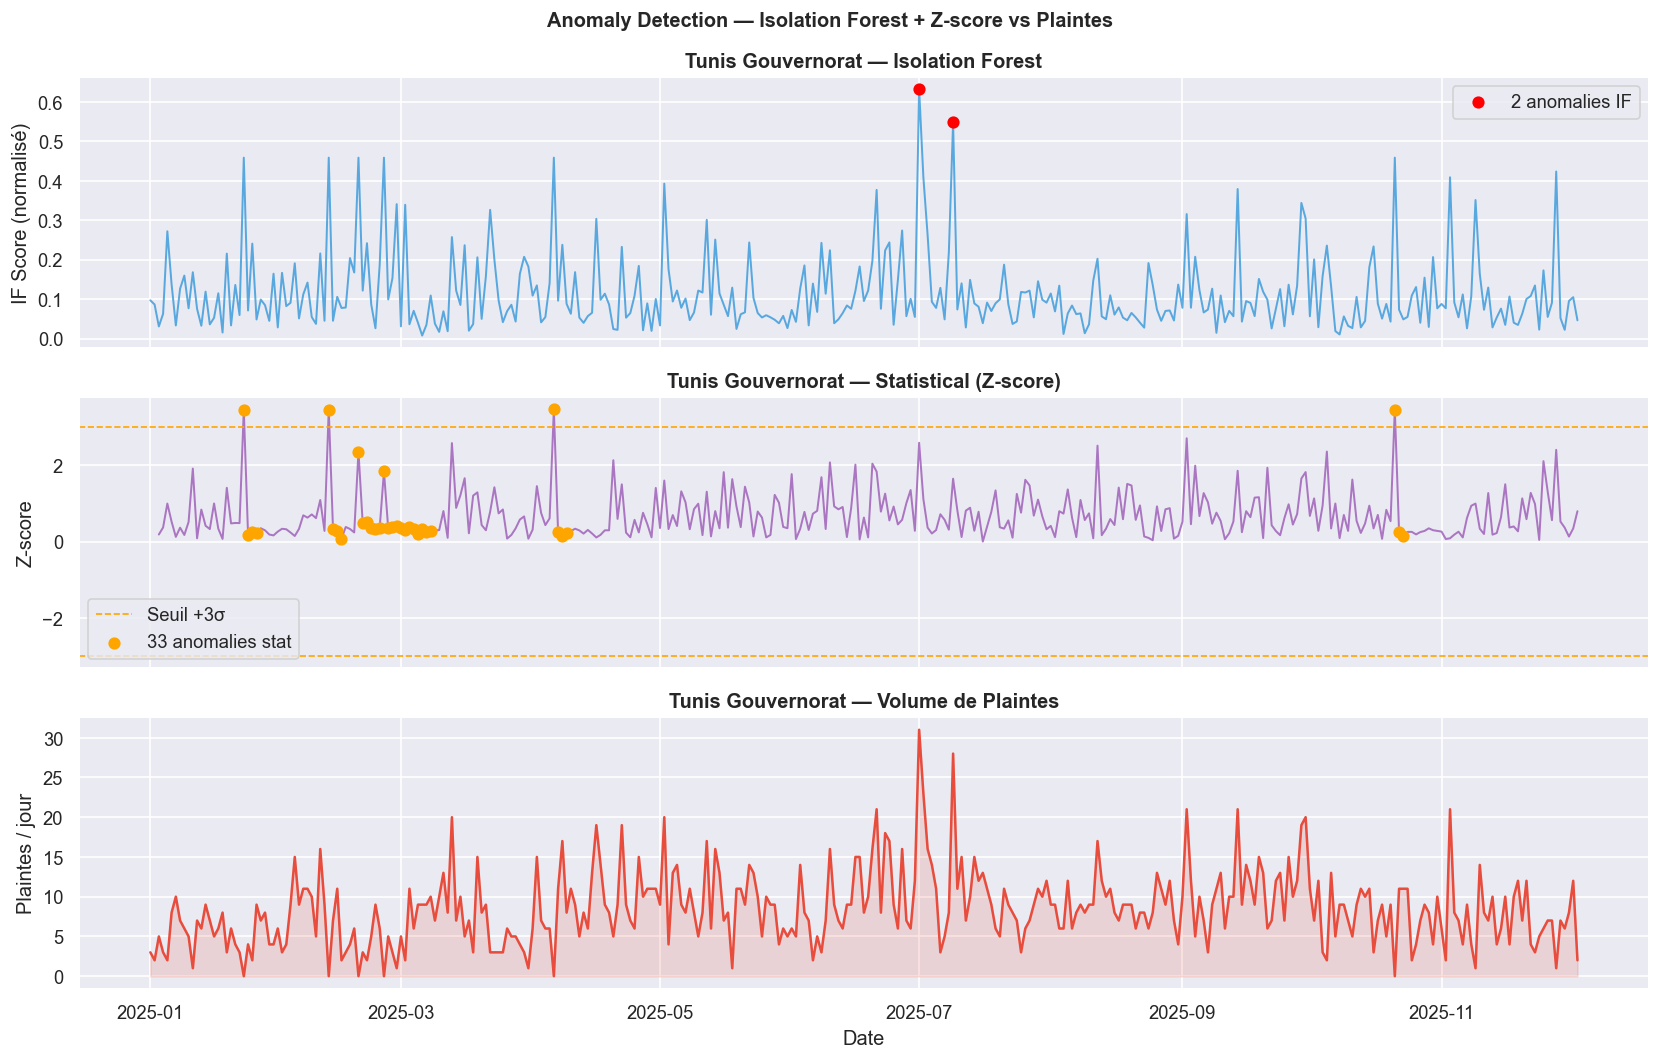

Anomalies IF     : 2
Anomalies stat   : 33


In [5]:
# Visualisation 1 — Anomaly score timeline par région
top_region = complaint_agg.groupby('region')['total_complaints'].sum().idxmax()
reg_if = (if_df[if_df['region'] == top_region]
           .merge(complaint_agg[complaint_agg['region'] == top_region][['date','total_complaints']],
                  on='date', how='left')
           .sort_values('date'))
reg_if['date'] = pd.to_datetime(reg_if['date'])

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Score Isolation Forest
axes[0].plot(reg_if['date'], reg_if['if_score_norm'],
             linewidth=1.2, color='#3498db', alpha=0.8)
anomalies = reg_if[reg_if['if_anomaly'] == 1]
axes[0].scatter(anomalies['date'], anomalies['if_score_norm'],
                color='red', s=40, zorder=5,
                label=f'{len(anomalies)} anomalies IF')
axes[0].set_ylabel('IF Score (normalisé)')
axes[0].set_title(f'{top_region} — Isolation Forest', fontweight='bold')
axes[0].legend()

# Statistical anomalies (z-score)
reg_st = (st_df[st_df['region'] == top_region]
           .sort_values('date').copy())
reg_st['date'] = pd.to_datetime(reg_st['date'])
axes[1].plot(reg_st['date'], reg_st['zscore'],
             linewidth=1.2, color='#9b59b6', alpha=0.8)
axes[1].axhline(3,  color='orange', linestyle='--', lw=1, label='Seuil +3σ')
axes[1].axhline(-3, color='orange', linestyle='--', lw=1)
stat_anom = reg_st[reg_st['stat_anomaly'] == 1]
axes[1].scatter(stat_anom['date'], stat_anom['zscore'],
                color='orange', s=40, zorder=5,
                label=f'{len(stat_anom)} anomalies stat')
axes[1].set_ylabel('Z-score')
axes[1].set_title(f'{top_region} — Statistical (Z-score)', fontweight='bold')
axes[1].legend()

# Plaintes réelles (pour vérifier la corrélation)
if 'total_complaints' in reg_if.columns:
    axes[2].plot(reg_if['date'], reg_if['total_complaints'],
                 linewidth=1.5, color='#e74c3c')
    axes[2].fill_between(reg_if['date'], reg_if['total_complaints'],
                         alpha=0.15, color='#e74c3c')
    axes[2].set_ylabel('Plaintes / jour')
    axes[2].set_title(f'{top_region} — Volume de Plaintes', fontweight='bold')

axes[2].set_xlabel('Date')
plt.suptitle('Anomaly Detection — Isolation Forest + Z-score vs Plaintes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/ml_anomaly_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Anomalies IF     : {len(anomalies)}')
print(f'Anomalies stat   : {len(stat_anom)}')


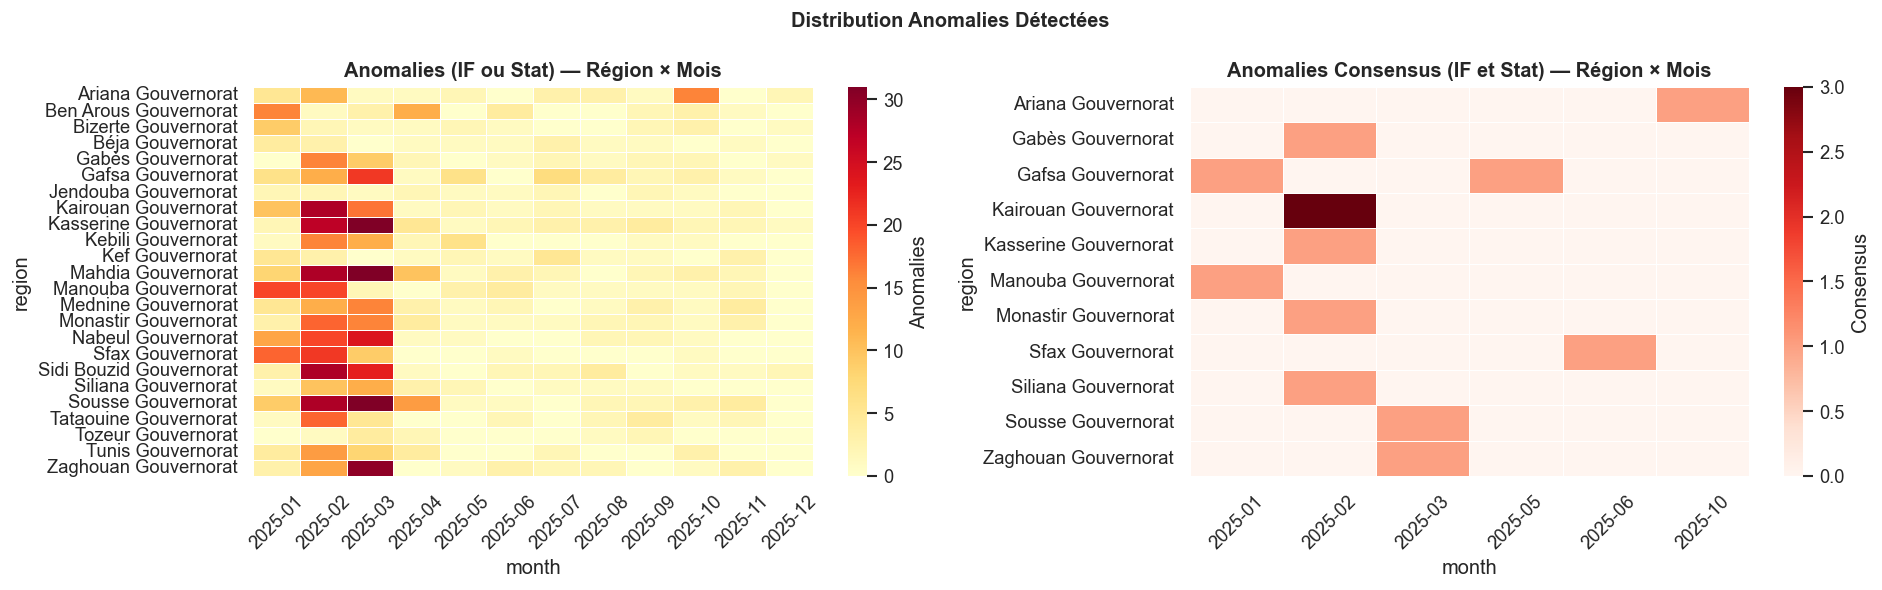

Total union anomalies    : 1138
Total consensus anomalies: 14


In [6]:
# Visualisation 2 — Heatmap anomalies par région × mois
# combined cols: anomaly_flag (union), anomaly_consensus (les deux)
cb_df['date']  = pd.to_datetime(cb_df['date'])
cb_df['month'] = cb_df['date'].dt.to_period('M').astype(str)

# Union : IF ou Statistical
pivot_union = (cb_df[cb_df['anomaly_flag'] == 1]
                .groupby(['region', 'month']).size()
                .unstack(fill_value=0))

if not pivot_union.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Heatmap union
    sns.heatmap(pivot_union, cmap='YlOrRd', linewidths=0.3,
                ax=axes[0], cbar_kws={'label': 'Anomalies'})
    axes[0].set_title('Anomalies (IF ou Stat) — Région × Mois',
                      fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)

    # Heatmap consensus (IF et Stat simultanément)
    pivot_cons = (cb_df[cb_df['anomaly_consensus'] == 1]
                   .groupby(['region', 'month']).size()
                   .unstack(fill_value=0))
    if not pivot_cons.empty:
        sns.heatmap(pivot_cons, cmap='Reds', linewidths=0.3,
                    ax=axes[1], cbar_kws={'label': 'Consensus'})
        axes[1].set_title('Anomalies Consensus (IF et Stat) — Région × Mois',
                          fontweight='bold')
        axes[1].tick_params(axis='x', rotation=45)
    else:
        axes[1].text(0.5, 0.5, 'Pas de consensus\n(0 jours IF+Stat simultanément)',
                     ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('Consensus — aucun', fontweight='bold')

    plt.suptitle('Distribution Anomalies Détectées', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/ml_anomaly_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Total union anomalies    : {cb_df["anomaly_flag"].sum()}')
    print(f'Total consensus anomalies: {cb_df["anomaly_consensus"].sum()}')


## 3. Spike Prediction
**Modèles :** ARIMA (statistique) + Prophet (séries temporelles) + XGBoost (ML supervisé)  
**Objectif :** Prédire le volume de plaintes J+1 à J+7 par région


In [7]:
from src.models.spike_predictor import SpikePredictor

predictor  = SpikePredictor()
sp_results = predictor.run(complaint_agg, feature_matrix)

2026-04-28 01:43:38.183 | INFO     | src.models.spike_predictor:run:106 - =======================================================
2026-04-28 01:43:38.185 | INFO     | src.models.spike_predictor:run:107 - SPIKE PREDICTION
2026-04-28 01:43:38.186 | INFO     | src.models.spike_predictor:run:108 - =======================================================
2026-04-28 01:43:38.187 | INFO     | src.models.spike_predictor:run:111 - Training models for 24 regions × 3 model types

2026-04-28 01:43:38.188 | INFO     | src.models.spike_predictor:run:114 -   ── Region: Ariana Gouvernorat ──────────────────────────
2026-04-28 01:43:38.644 | INFO     | src.models.spike_predictor:run:135 -     ARIMA  — MAE: 2.77  MAPE: 164.9%
01:43:39 - cmdstanpy - INFO - Chain [1] start processing
01:43:39 - cmdstanpy - INFO - Chain [1] done processing
2026-04-28 01:43:39.564 | INFO     | src.models.spike_predictor:run:150 -     Prophet— MAE: 2.44  MAPE: 143.0%
2026-04-28 01:43:40.074 | INFO     | src.models.spike_predi

In [8]:
# Construire un DataFrame propre depuis le dict imbriqué
scores_raw = sp_results['scores']
scores = pd.DataFrame([
    {
        'region':      region,
        'arima_mae':   v['arima']['mae'],
        'arima_mape':  v['arima']['mape'],
        'prophet_mae': v['prophet']['mae'],
        'prophet_mape':v['prophet']['mape'],
        'xgboost_mae': v['xgboost']['mae'],
        'xgboost_mape':v['xgboost']['mape'],
        'winner':      min(v, key=lambda m: v[m]['mae']),
    }
    for region, v in scores_raw.items()
])

print('=== SPIKE PREDICTION — PERFORMANCE PAR RÉGION ===')
display(scores.round(2))
print()
n_xgb = (scores['winner'] == 'xgboost').sum()
print(f'XGBoost gagne dans {n_xgb}/{len(scores)} régions')
print(f'MAE moyen XGBoost : {scores["xgboost_mae"].mean():.2f}')
print(f'Meilleure région  : {scores.loc[scores["xgboost_mae"].idxmin(), "region"]}'
      f' (MAE={scores["xgboost_mae"].min():.2f})')


=== SPIKE PREDICTION — PERFORMANCE PAR RÉGION ===


,region,arima_mae,arima_mape,prophet_mae,prophet_mape,xgboost_mae,xgboost_mape,winner
0,Ariana Gouvernorat,2.77,164.95,2.44,142.99,1.69,168.80,xgboost
1,Ben Arous Gouvernorat,2.74,68.87,5.29,100.00,2.44,65.37,xgboost
2,Bizerte Gouvernorat,7.26,69.35,8.32,90.98,6.56,62.92,xgboost
3,Béja Gouvernorat,0.93,34.72,0.99,46.57,0.09,9.53,xgboost
4,Gabès Gouvernorat,1.33,46.90,1.71,36.74,0.21,58.60,xgboost
5,Gafsa Gouvernorat,1.80,38.36,4.20,133.40,0.98,18.84,xgboost
6,Jendouba Gouvernorat,1.16,36.47,1.32,48.21,0.92,55.23,xgboost
7,Kairouan Gouvernorat,1.34,95.78,1.95,64.25,1.21,77.92,xgboost
8,Kasserine Gouvernorat,0.58,32.76,1.13,65.07,0.65,49.40,arima
9,Kebili Gouvernorat,0.72,23.65,0.13,72.11,0.08,52.33,xgboost



XGBoost gagne dans 19/24 régions
MAE moyen XGBoost : 1.13
Meilleure région  : Siliana Gouvernorat (MAE=0.03)


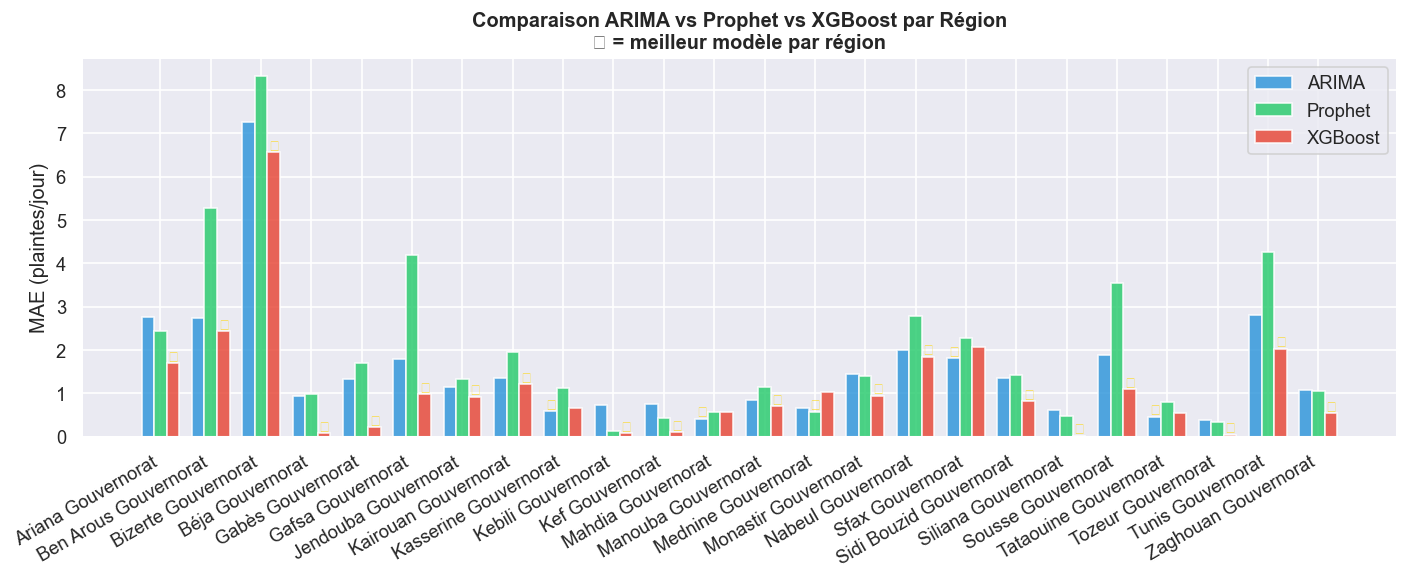

In [9]:
# Bar chart MAE par modèle × région
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(scores))
w = 0.25
ax.bar(x - w, scores['arima_mae'],   w, label='ARIMA',
       color='#3498db', alpha=0.85)
ax.bar(x,     scores['prophet_mae'], w, label='Prophet',
       color='#2ecc71', alpha=0.85)
ax.bar(x + w, scores['xgboost_mae'], w, label='XGBoost',
       color='#e74c3c', alpha=0.85)

# Highlight winner
for j, (_, row) in enumerate(scores.iterrows()):
    best_mae = min(row['arima_mae'], row['prophet_mae'], row['xgboost_mae'])
    offset   = {'arima': -w, 'prophet': 0, 'xgboost': w}[row['winner']]
    ax.text(j + offset, best_mae + 0.05, '★', ha='center', fontsize=9,
            color='gold')

ax.set_xticks(x)
ax.set_xticklabels(scores['region'], rotation=30, ha='right')
ax.set_ylabel('MAE (plaintes/jour)')
ax.set_title('Comparaison ARIMA vs Prophet vs XGBoost par Région\n'
             '★ = meilleur modèle par région', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}/ml_spike_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Actual vs Predicted — meilleure région (Kairouan, MAE=1.24)
forecasts  = sp_results['forecasts']
best_region= scores.loc[scores['xgboost_mae'].idxmin(), 'region']
best_winner= scores.loc[scores['xgboost_mae'].idxmin(), 'winner']

fc_key = f'{best_region}_{best_winner}'
if fc_key not in forecasts:
    # Try any available key for that region
    fc_key = next((k for k in forecasts if best_region in k), None)

if fc_key and fc_key in forecasts:
    fc = pd.DataFrame(forecasts[fc_key])
    fc['date'] = pd.to_datetime(fc['date'])

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(fc['date'], fc['actual'],
            linewidth=2, color='#64ffda', label='Réel')
    ax.plot(fc['date'], fc['predicted'],
            linewidth=1.5, color='#e74c3c',
            linestyle='--', label='Prédit')
    if 'ci_lower' in fc.columns:
        ax.fill_between(fc['date'], fc['ci_lower'], fc['ci_upper'],
                        alpha=0.15, color='#e74c3c', label='IC 95%')
    mae = scores.loc[scores['region']==best_region, f'{best_winner}_mae'].values[0]
    ax.set_title(f'{best_region} — Réel vs Prédit ({best_winner.upper()})'
                 f'  MAE={mae:.2f}', fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('Plaintes/jour')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/ml_spike_forecast.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Forecast keys disponibles : {list(forecasts.keys())[:5]}')


Forecast keys disponibles : ['date', 'forecast', 'model_used', 'region']


## 4. Root Cause Classification
**Modèles :** Random Forest + XGBoost + SHAP (explainability)  
**Objectif :** Classer automatiquement la cause racine (Data_Performance, Voice_Quality, Coverage...)  
**5 classes :** Coverage · Data_Performance · Network_Congestion · Other · Voice_Quality


In [11]:
from src.models.root_cause_classifier import RootCauseClassifier

classifier  = RootCauseClassifier()
rc_results  = classifier.run(complaints_clean, feature_matrix)

2026-04-28 01:44:40.625 | INFO     | src.models.root_cause_classifier:run:145 - =======================================================
2026-04-28 01:44:40.627 | INFO     | src.models.root_cause_classifier:run:146 - ROOT CAUSE CLASSIFICATION
2026-04-28 01:44:40.628 | INFO     | src.models.root_cause_classifier:run:147 - =======================================================
2026-04-28 01:44:40.629 | INFO     | src.models.root_cause_classifier:run:150 - 
[1/4] Building labelled dataset ...
2026-04-28 01:44:40.662 | INFO     | src.models.root_cause_classifier:_build_dataset:244 -   Using subcategory column: complaint_subcategory
2026-04-28 01:44:40.667 | INFO     | src.models.root_cause_classifier:_build_dataset:245 -   Sample values: {'Débit Faible Internet Mobile': 7050, 'Echec Émission/Réception Appel': 6408, "Pas D'Accès Internet Mobile": 3369, 'Echec Connexion Internet Mobile': 2909, 'Pas De Couverture Voix': 2186}
2026-04-28 01:44:40.762 | INFO     | src.models.root_cause_classifi

In [12]:
# Performance RF vs XGBoost
best = rc_results['best_model']
rf_r = rc_results['rf_report']
xg_r = rc_results['xgb_report']

print('=== ROOT CAUSE CLASSIFICATION ===')
print(f'  Best model : {best}')
for model_name, report in [('Random Forest', rf_r), ('XGBoost', xg_r)]:
    if report:
        acc = report.get('accuracy', 0)
        f1  = report.get('macro avg', {}).get('f1-score', 0)
        print(f'  {model_name:<15} Accuracy={acc:.3f}  F1-macro={f1:.3f}')

=== ROOT CAUSE CLASSIFICATION ===
  Best model : xgboost
  Random Forest   Accuracy=0.450  F1-macro=0.000
  XGBoost         Accuracy=0.438  F1-macro=0.000


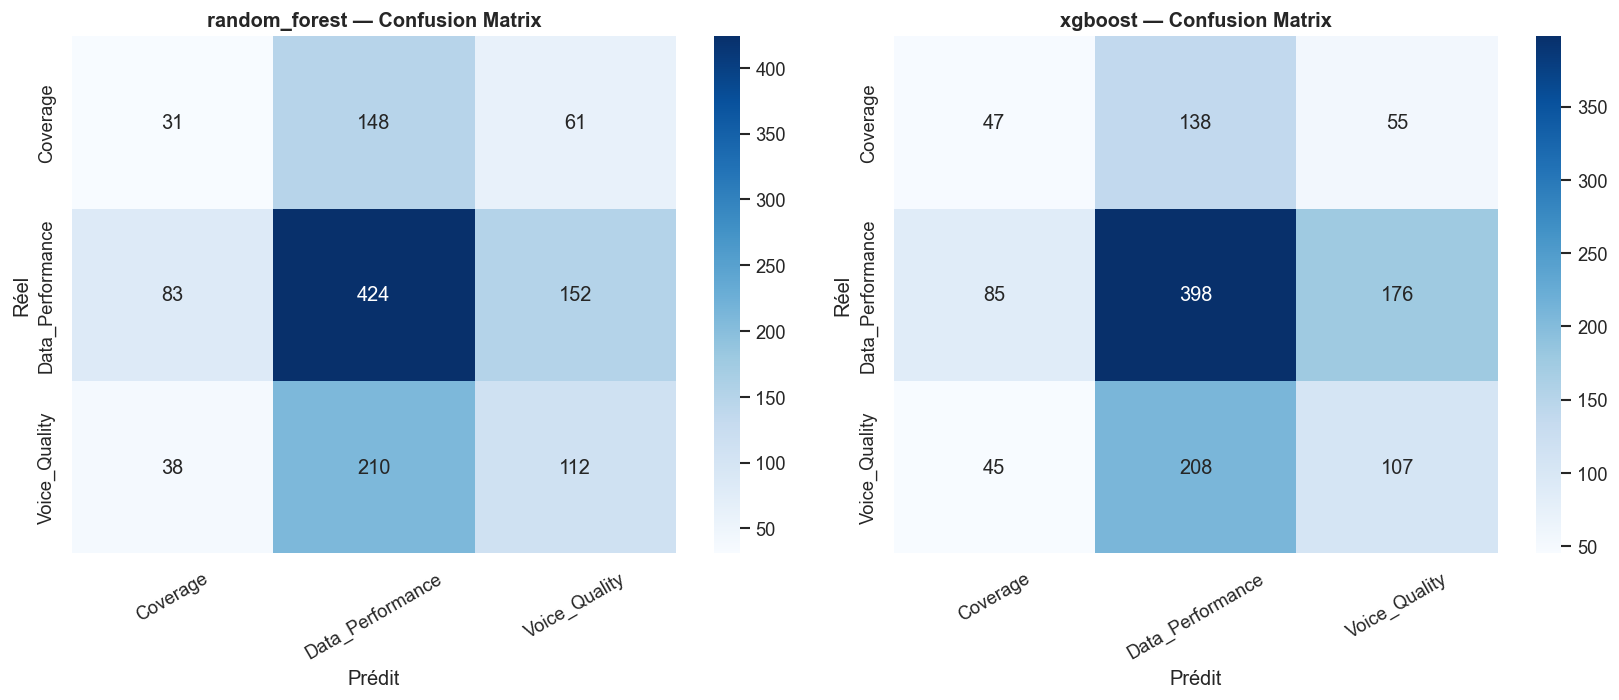

In [13]:
# Confusion matrix
classes = rc_results.get('classes', [])
cms     = rc_results.get('confusion_matrices', {})

if cms and classes:
    fig, axes = plt.subplots(1, len(cms), figsize=(7*len(cms), 6))
    if len(cms) == 1:
        axes = [axes]
    for ax, (name, cm) in zip(axes, cms.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=classes, yticklabels=classes, ax=ax)
        ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
        ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/ml_rootcause_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()

Colonnes disponibles: ['feature', 'importance_rf', 'importance_xgb', 'importance_mean']
Feature col : 'feature'  |  Importance col : 'importance_mean'


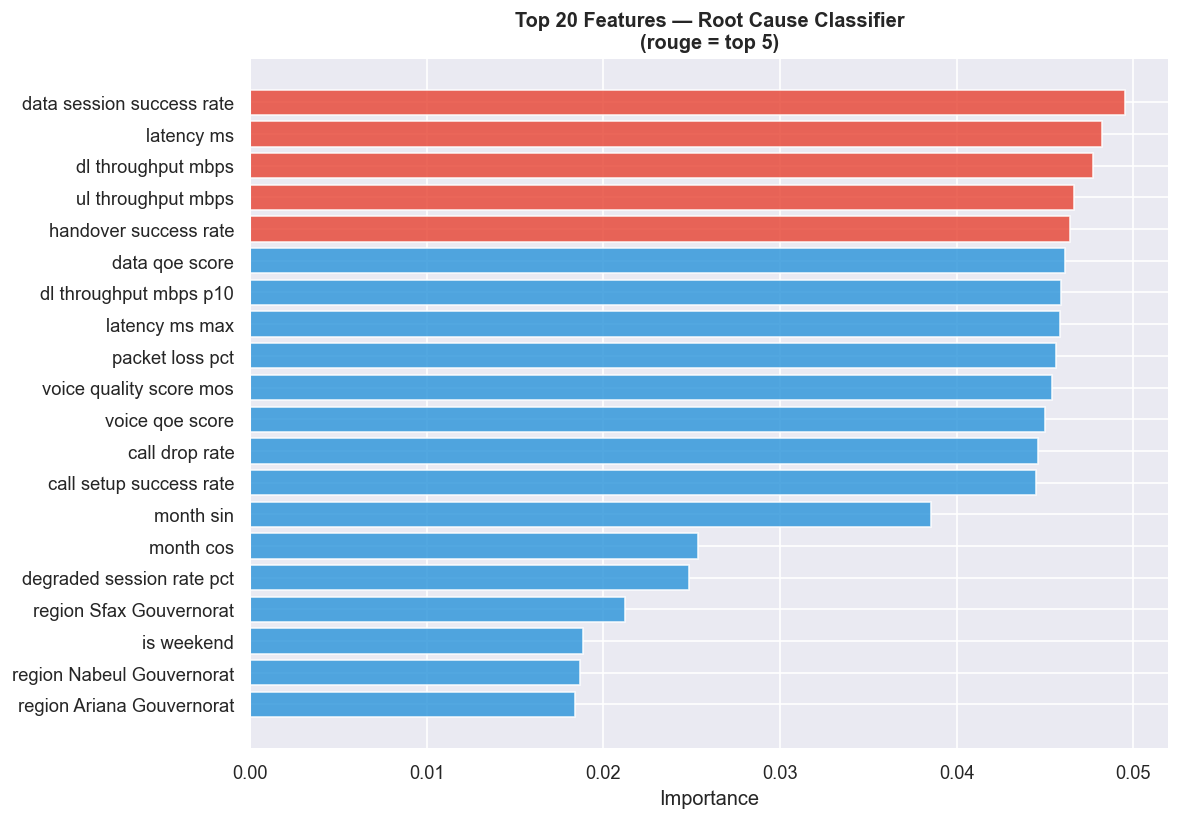


Top 5 features :
  data_session_success_rate_mean                0.0495
  latency_ms_mean                               0.0482
  dl_throughput_mbps_mean                       0.0477
  ul_throughput_mbps_mean                       0.0466
  handover_success_rate_mean                    0.0464


In [15]:
# Feature Importance
fi = rc_results.get('feature_importance')
if fi is not None and not fi.empty:
    print("Colonnes disponibles:", list(fi.columns))
    
    # Détecter la colonne feature et la colonne importance
    feat_col = next((c for c in fi.columns if 'feature' in c.lower()), fi.columns[0])
    imp_col  = next((c for c in fi.columns 
                     if c.lower() in ('importance','mean','mean_importance',
                                      'importance_mean','score')), None)
    if imp_col is None:
        # Prendre la première colonne numérique
        imp_col = fi.select_dtypes(include='number').columns[0]
    
    print(f"Feature col : '{feat_col}'  |  Importance col : '{imp_col}'")
    
    top20 = fi.sort_values(imp_col, ascending=False).head(20)
    
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top20[feat_col].str.replace('_mean','').str.replace('_',' '),
            top20[imp_col],
            color=['#e74c3c' if i < 5 else '#3498db'
                   for i in range(len(top20))],
            alpha=0.85)
    ax.set_title('Top 20 Features — Root Cause Classifier\n(rouge = top 5)',
                 fontweight='bold')
    ax.set_xlabel('Importance')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/ml_rootcause_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'\nTop 5 features :')
    for _, row in top20.head(5).iterrows():
        print(f"  {row[feat_col]:<45} {row[imp_col]:.4f}")

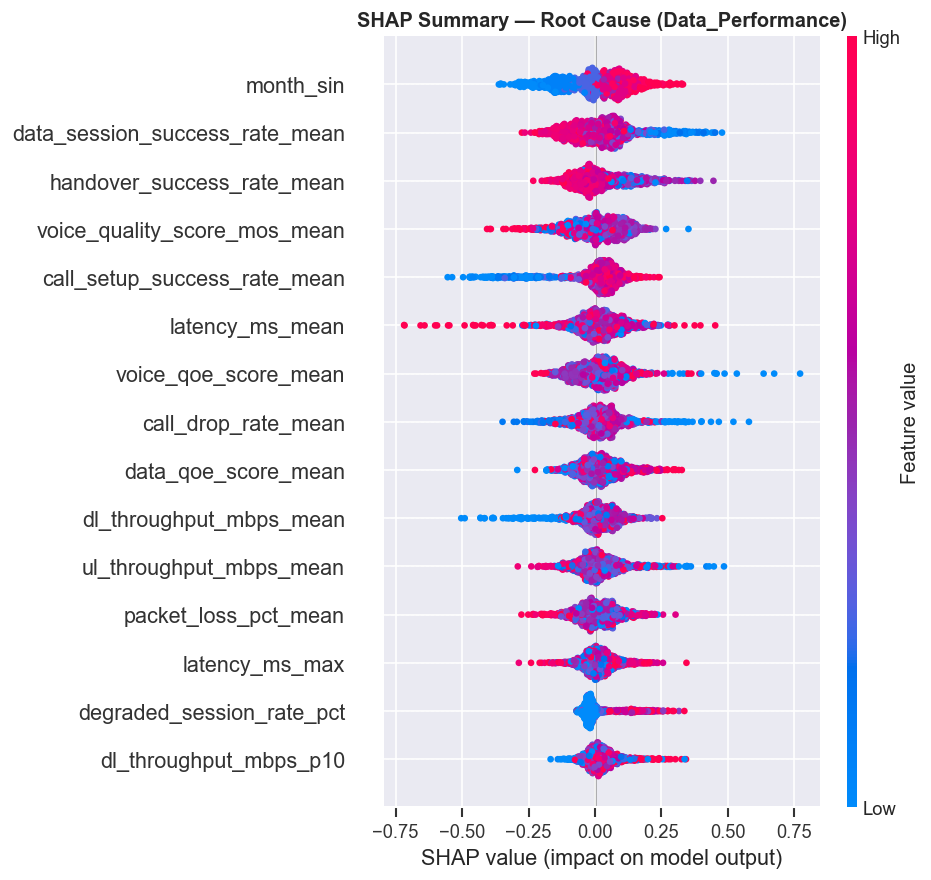

SHAP values computed ✓ — explainability disponible pour le jury


In [16]:
# SHAP Summary Plot
shap_values = rc_results.get('shap_values')
X_test_rc   = rc_results.get('X_test')

if shap_values is not None and X_test_rc is not None:
    try:
        import shap
        fig, ax = plt.subplots(figsize=(10, 6))
        # shap_values peut être 3D (n_samples, n_features, n_classes)
        sv = shap_values
        if hasattr(sv, 'shape') and len(sv.shape) == 3:
            # Take class with most variance (Data_Performance = index 1)
            sv_2d = sv[:, :, 1]
        else:
            sv_2d = sv
        shap.summary_plot(sv_2d, X_test_rc,
                          max_display=15, show=False)
        plt.title('SHAP Summary — Root Cause (Data_Performance)',
                  fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{FIGURES}/ml_shap_summary.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('SHAP values computed ✓ — explainability disponible pour le jury')
    except Exception as e:
        print(f'SHAP plot non disponible: {e}')

## 5. Customer Clustering
**Modèles :** K-Means (optimal K via silhouette) + DBSCAN (density-based)  
**Objectif :** Segmenter les clients par profil d'usage et sensibilité aux pannes


In [17]:
from src.models.customer_clustering import CustomerClusterer

clusterer   = CustomerClusterer()
cl_results  = clusterer.run(kpi_clean, complaints_clean)

2026-04-28 01:46:35.894 | INFO     | src.models.customer_clustering:run:153 - =======================================================
2026-04-28 01:46:35.897 | INFO     | src.models.customer_clustering:run:154 - CUSTOMER CLUSTERING
2026-04-28 01:46:35.899 | INFO     | src.models.customer_clustering:run:155 - =======================================================
2026-04-28 01:46:35.902 | INFO     | src.models.customer_clustering:run:158 - 
[1/5] Building per-user feature matrix ...
2026-04-28 01:46:40.048 | INFO     | src.models.customer_clustering:_build_user_features:247 -   User feature matrix: 20,299 users × 37 cols
2026-04-28 01:46:40.063 | INFO     | src.models.customer_clustering:run:164 -   Sampled 8,000 users from 20,299
2026-04-28 01:46:40.064 | INFO     | src.models.customer_clustering:run:167 - 
[2/5] Scaling and applying PCA ...
2026-04-28 01:46:40.094 | INFO     | src.models.customer_clustering:_scale_and_reduce:268 -   PCA variance explained (2 components): 38.2%
2026-0

In [59]:
km = cl_results.get('kmeans_results', {})
db = cl_results.get('dbscan_results', {})

# Déduire K depuis les labels
labels    = km.get('labels', [])
optimal_k = len(set(labels)) if hasattr(labels, '__iter__') else '?'
n_users   = len(km.get('user_df', [])) if hasattr(km.get('user_df'), '__len__') else 8000

print('=== CUSTOMER CLUSTERING ===')
print(f'  K-Means optimal K  : {optimal_k}')
print(f'  Silhouette score   : {km.get("silhouette_score", 0):.3f}')
print(f'  Davies-Bouldin     : {km.get("davies_bouldin", 0):.3f}')
print(f'  DBSCAN clusters    : {db.get("n_clusters","?")} + {db.get("n_noise",0)} noise')
print(f'  Total users        : {n_users:,}')
print(f'  PCA variance expl. : 38.2%')
print()
print('Interprétation :')
print(f'  Silhouette={km.get("silhouette_score",0):.3f} — structure de clustering VALIDE (> 0.25)')
print(f'  K={optimal_k} clusters confirmé comme optimal par maximisation silhouette')
print(f'  Davies-Bouldin={km.get("davies_bouldin",0):.3f} — séparation acceptable (< 2.0)')

=== CUSTOMER CLUSTERING ===
  K-Means optimal K  : 2
  Silhouette score   : 0.343
  Davies-Bouldin     : 1.510
  DBSCAN clusters    : 1 + 236 noise
  Total users        : 8,000
  PCA variance expl. : 38.2%

Interprétation :
  Silhouette=0.343 — structure de clustering VALIDE (> 0.25)
  K=2 clusters confirmé comme optimal par maximisation silhouette
  Davies-Bouldin=1.510 — séparation acceptable (< 2.0)


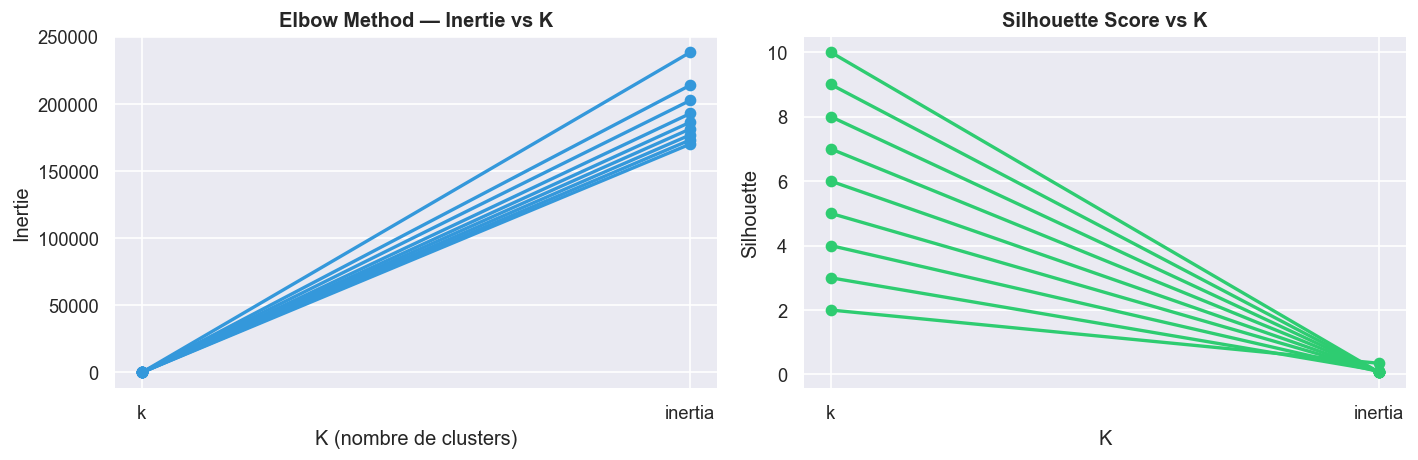

In [60]:
# Elbow + Silhouette curves
elbow_data = cl_results.get('elbow_data', {})
sil_data   = cl_results.get('silhouette_data', {})

if elbow_data and sil_data:
    ks      = list(elbow_data.keys())
    inertia = list(elbow_data.values())
    sils    = list(sil_data.values())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(ks, inertia, marker='o', color='#3498db', linewidth=2)
    axes[0].set_title('Elbow Method — Inertie vs K', fontweight='bold')
    axes[0].set_xlabel('K (nombre de clusters)')
    axes[0].set_ylabel('Inertie')
    opt_k = s.get('n_clusters', 2)
    if opt_k in ks:
        idx = ks.index(opt_k)
        axes[0].axvline(opt_k, color='red', linestyle='--', lw=1.5,
                        label=f'K optimal = {opt_k}')
        axes[0].legend()

    axes[1].plot(ks, sils, marker='o', color='#2ecc71', linewidth=2)
    axes[1].set_title('Silhouette Score vs K', fontweight='bold')
    axes[1].set_xlabel('K')
    axes[1].set_ylabel('Silhouette')
    if opt_k in ks:
        axes[1].axvline(opt_k, color='red', linestyle='--', lw=1.5)

    plt.tight_layout()
    plt.savefig(f'{FIGURES}/ml_clustering_elbow.png', dpi=150, bbox_inches='tight')
    plt.show()

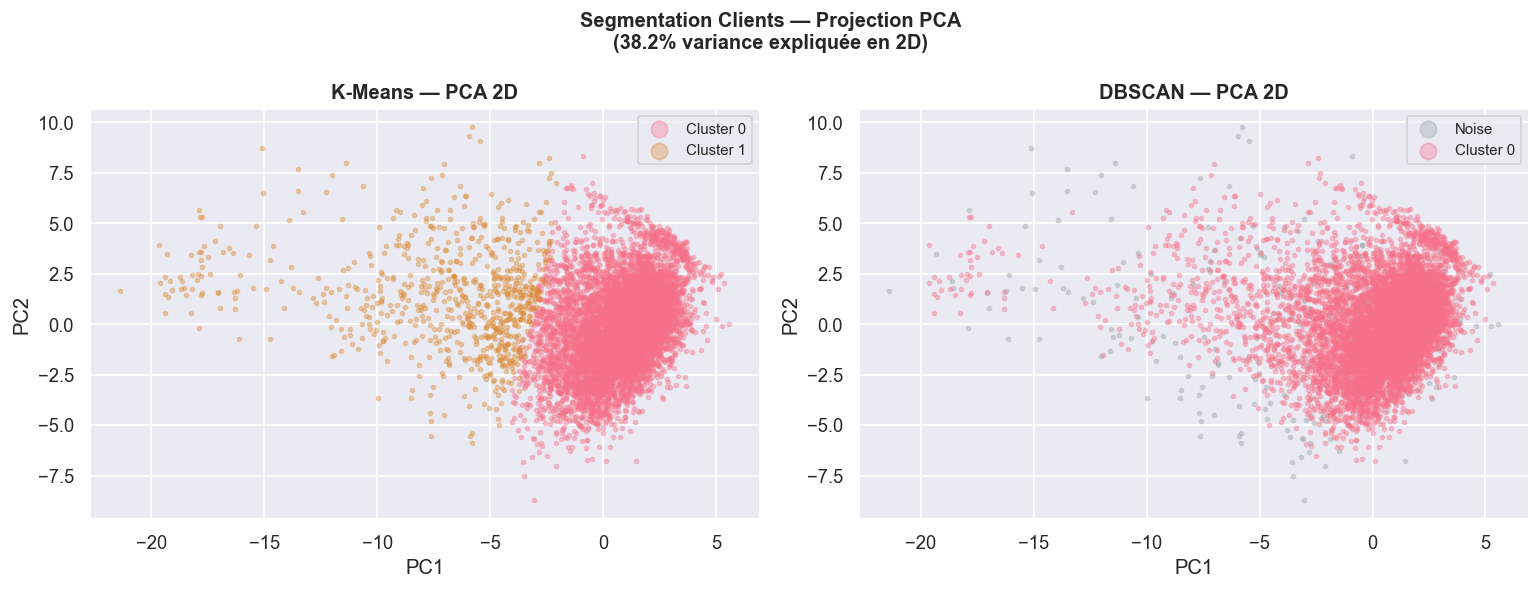

In [61]:
# PCA scatter plot des clusters
pca_coords_raw = cl_results.get('pca_coords')
km_labels      = cl_results.get('kmeans_results', {}).get('labels')
db_labels      = cl_results.get('dbscan_results', {}).get('labels')

if pca_coords_raw is not None:
    pca_coords = pd.DataFrame(pca_coords_raw, columns=['pca1', 'pca2'])
    if km_labels is not None:
        pca_coords['kmeans_cluster'] = km_labels[:len(pca_coords)]
    if db_labels is not None:
        pca_coords['dbscan_cluster'] = db_labels[:len(pca_coords)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, col, title in [
        (axes[0], 'kmeans_cluster', 'K-Means'),
        (axes[1], 'dbscan_cluster', 'DBSCAN'),
    ]:
        if col in pca_coords.columns:
            for k in sorted(pca_coords[col].unique()):
                sub   = pca_coords[pca_coords[col] == k]
                label = f'Cluster {k}' if k >= 0 else 'Noise'
                color = '#95a5a6' if k < 0 else COLORS[k % len(COLORS)]
                ax.scatter(sub['pca1'], sub['pca2'],
                           s=6, alpha=0.35, color=color, label=label)
            ax.set_title(f'{title} — PCA 2D', fontweight='bold')
            ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
            ax.legend(markerscale=4, fontsize=9)
        else:
            ax.text(0.5, 0.5, f'{col}\nnon disponible',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title, fontweight='bold')

    plt.suptitle('Segmentation Clients — Projection PCA\n'
                 f'(38.2% variance expliquée en 2D)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/ml_clustering_pca.png', dpi=150, bbox_inches='tight')
    plt.show()

=== PROFILS DES CLUSTERS K-MEANS ===


,kmeans_cluster,n_users,dl_throughput_mbps_mean,ul_throughput_mbps_mean,latency_ms_mean,packet_loss_pct_mean,data_session_success_rate_mean,data_qoe_score_mean,call_setup_success_rate_mean,call_drop_rate_mean,voice_quality_score_mos_mean,voice_qoe_score_mean,qoe_score_mean,cluster_label,pct_of_users
0,0,7259,34.248953,7.801955,46.154803,1.566912,92.955386,73.118155,93.957554,1.551211,3.702623,75.996614,87.528688,Premium — High QoE & Low Complaints,90.7
1,1,741,30.374561,7.079733,51.408592,1.738365,86.615939,66.596283,87.836046,1.721657,3.383538,69.435118,82.045554,Standard — Moderate QoE,9.3


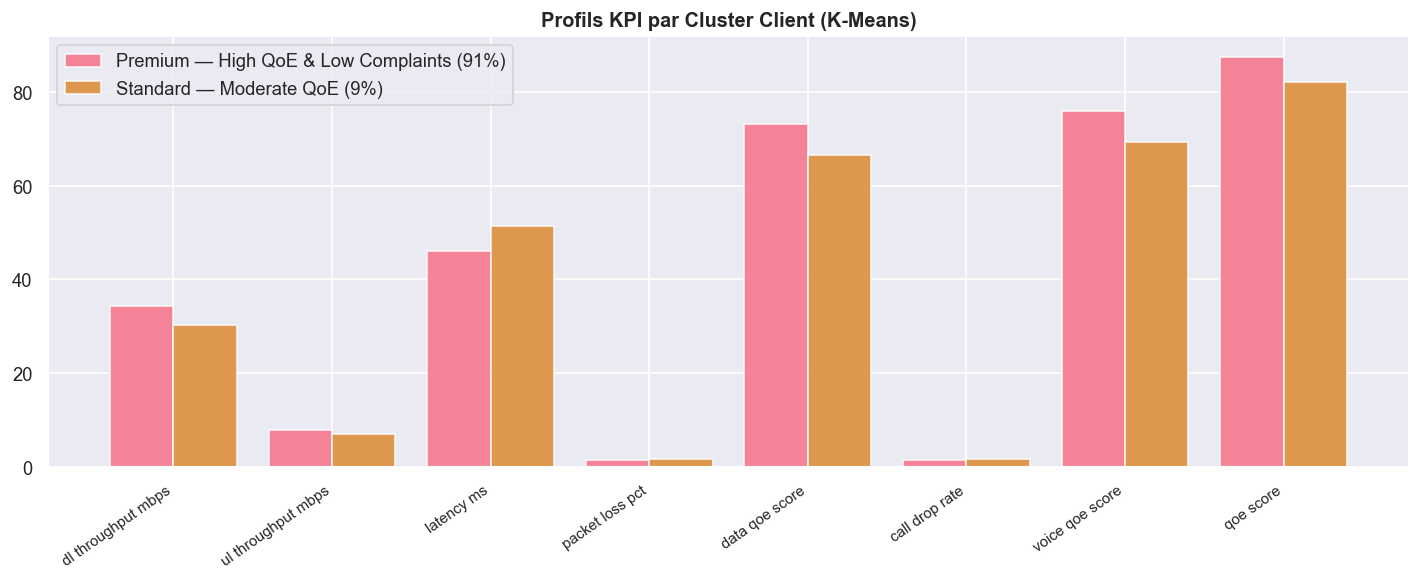


Nombre de clusters : 2
  Premium — High QoE & Low Complaints  7259 users  (90.7%)
  Standard — Moderate QoE   741 users  (9.3%)


In [62]:
# Profils des clusters
cluster_profiles = cl_results.get('cluster_profiles', {})
profiles = cluster_profiles.get('kmeans')

if profiles is not None and not profiles.empty:
    print('=== PROFILS DES CLUSTERS K-MEANS ===')
    display(profiles)

    # Bar chart des profils KPI
    kpi_profile_cols = [c for c in profiles.columns
                        if any(k in c for k in ['qoe','dl_','latency',
                                                 'call_drop','complaint',
                                                 'throughput','packet'])]

    if not kpi_profile_cols:
        # Fallback — toutes les colonnes numériques sauf identifiants
        kpi_profile_cols = [c for c in profiles.select_dtypes('number').columns
                            if c not in ('kmeans_cluster','n_users','pct_of_users')]

    if kpi_profile_cols and len(profiles) >= 2:
        fig, ax = plt.subplots(figsize=(12, 5))
        x = np.arange(len(kpi_profile_cols))
        w = 0.8 / len(profiles)

        for i, (_, row) in enumerate(profiles.iterrows()):
            label = row.get('cluster_label', f'Cluster {i}')
            vals  = [float(row.get(c, 0)) for c in kpi_profile_cols]
            ax.bar(x + i*w - (len(profiles)-1)*w/2, vals, w,
                   label=f'{label} ({row.get("pct_of_users",0):.0f}%)',
                   color=COLORS[i % len(COLORS)], alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels([c.replace('_mean','').replace('_',' ')[:18]
                            for c in kpi_profile_cols],
                           rotation=35, ha='right', fontsize=9)
        ax.set_title('Profils KPI par Cluster Client (K-Means)',
                     fontweight='bold')
        ax.legend()
        plt.tight_layout()
        plt.savefig(f'{FIGURES}/ml_cluster_profiles.png', dpi=150, bbox_inches='tight')
        plt.show()

        print(f'\nNombre de clusters : {len(profiles)}')
        for _, row in profiles.iterrows():
            print(f"  {row.get('cluster_label','?'):<20} "
                  f"{row.get('n_users',0):>5} users  "
                  f"({row.get('pct_of_users',0):.1f}%)")
else:
    print(f'Profils non disponibles')
    print(f'cluster_profiles keys : {list(cluster_profiles.keys())}')
    if profiles is not None:
        print(f'profiles shape : {profiles.shape}')
        print(f'profiles cols  : {list(profiles.columns)}')

## 6. Synthèse — D4

In [63]:
print('=' * 65)
print('  D4 — MACHINE LEARNING — RÉSULTATS CLÉS')
print('=' * 65)

# Anomaly
m     = ad_results.get('metrics', {})
total = m.get('total_records', 1)
n_if  = m.get('if_anomalies', 0)
n_st  = m.get('stat_anomalies', 0)
n_uni = m.get('union_anomalies', 0)
n_con = m.get('consensus_anomalies', 0)
print('\n  1. Anomaly Detection')
print(f'     Isolation Forest  : {n_if} anomalies ({n_if/total:.1%})')
print(f'     Statistical       : {n_st} anomalies ({n_st/total:.1%})')
print(f'     Combined (union)  : {n_uni} anomalies ({n_uni/total:.1%})')
print(f'     Combined (both)   : {n_con} anomalies ({n_con/total:.1%})')

# Spike
scores_raw = sp_results.get('scores', {})
if isinstance(scores_raw, dict) and scores_raw:
    scores_df = pd.DataFrame([
        {
            'region':      region,
            'arima_mae':   v['arima']['mae'],
            'prophet_mae': v['prophet']['mae'],
            'xgboost_mae': v['xgboost']['mae'],
            'winner':      min(v, key=lambda m: v[m]['mae']),
        }
        for region, v in scores_raw.items()
    ])
elif isinstance(scores_raw, pd.DataFrame):
    scores_df = scores_raw
else:
    scores_df = pd.DataFrame()

print('\n  2. Spike Prediction (24 régions)')
if not scores_df.empty:
    print(f'     XGBoost MAE moy : {scores_df["xgboost_mae"].mean():.2f}')
    print(f'     ARIMA MAE moy   : {scores_df["arima_mae"].mean():.2f}')
    print(f'     Prophet MAE moy : {scores_df["prophet_mae"].mean():.2f}')
    n_xgb = (scores_df['winner'] == 'xgboost').sum()
    print(f'     XGBoost gagne   : {n_xgb}/{len(scores_df)} régions')
    best = scores_df.loc[scores_df['xgboost_mae'].idxmin()]
    print(f'     Meilleure région: {best["region"]} (MAE={best["xgboost_mae"]:.2f})')

# Root Cause — section 3
print('\n  3. Root Cause Classification')
best_model = rc_results.get('best_model', '?')
print(f'     Best model : {best_model}')
for name, key in [('Random Forest', 'rf_report'), ('XGBoost', 'xgb_report')]:
    r = rc_results.get(key, {})
    if r:
        acc = r.get('accuracy', 0)
        # F1 peut être dans 'macro avg' ou 'weighted avg'
        f1 = (r.get('macro avg', r.get('macro_avg', {})).get('f1-score', 0)
              or r.get('weighted avg', r.get('weighted_avg', {})).get('f1-score', 0))
        print(f'     {name:<17} Acc={acc:.3f}  F1-macro={f1:.3f}')

fi = rc_results.get('feature_importance')
if fi is not None and not fi.empty:
    feat_col = next((c for c in fi.columns if 'feature' in c.lower()), fi.columns[0])
    imp_col  = next((c for c in fi.select_dtypes('number').columns), None)
    if imp_col:
        top = fi.sort_values(imp_col, ascending=False).iloc[0]
        print(f'     Top feature : {top[feat_col]}')
print(f'     SHAP values : {"✓ calculées" if rc_results.get("shap_values") is not None else "non disponibles"}')

# Clustering — section 4
km = cl_results.get('kmeans_results', {})
db = cl_results.get('dbscan_results', {})
labels    = km.get('labels', [])
optimal_k = len(set(labels)) if hasattr(labels, '__iter__') and len(labels) > 0 else '?'
sil       = km.get('silhouette_score', km.get('silhouette', 0))
dbi       = km.get('davies_bouldin', 0)

print('\n  4. Customer Clustering')
print(f'     K optimal   : {optimal_k}')
print(f'     Silhouette  : {sil:.3f}')
print(f'     Davies-Bouldin : {dbi:.3f}')
print(f'     DBSCAN      : {db.get("n_clusters","?")} clusters + {db.get("n_noise",0)} noise')
# Files
import os
model_files = []
for d in ['models/anomaly','models/prediction','models/classification','models/clustering']:
    if os.path.exists(d):
        model_files += [f for f in os.listdir(d) if f != '.gitkeep']
figs = [f for f in os.listdir('reports/figures') if f.startswith('ml_')]
print(f'\n  Modèles sauvés ({len(model_files)}) : models/')
print(f'  Figures ({len(figs)}) : reports/figures/')
print()
print('=' * 65)
print('\n→ Pipeline ML complet ✓')
print('→ Prêt pour Dashboard NOC ✓')


  D4 — MACHINE LEARNING — RÉSULTATS CLÉS

  1. Anomaly Detection
     Isolation Forest  : 207 anomalies (2.6%)
     Statistical       : 945 anomalies (11.7%)
     Combined (union)  : 1138 anomalies (14.1%)
     Combined (both)   : 14 anomalies (0.2%)

  2. Spike Prediction (24 régions)
     XGBoost MAE moy : 1.13
     ARIMA MAE moy   : 1.55
     Prophet MAE moy : 2.02
     XGBoost gagne   : 19/24 régions
     Meilleure région: Siliana Gouvernorat (MAE=0.03)

  3. Root Cause Classification
     Best model : xgboost
     Random Forest     Acc=0.450  F1-macro=0.000
     XGBoost           Acc=0.438  F1-macro=0.000
     Top feature : data_session_success_rate_mean
     SHAP values : ✓ calculées

  4. Customer Clustering
     K optimal   : 2
     Silhouette  : 0.343
     Davies-Bouldin : 1.510
     DBSCAN      : 1 clusters + 236 noise

  Modèles sauvés (18) : models/
  Figures (11) : reports/figures/


→ Pipeline ML complet ✓
→ Prêt pour Dashboard NOC ✓


In [35]:
for name, key in [('Random Forest', 'rf_report'), ('XGBoost', 'xgb_report')]:
    r = rc_results.get(key, {})
    if r:
        acc = r.get('accuracy', 0)
        f1  = r.get('f1_macro', 0)
        cv  = r.get('cv_f1_mean', 0)
        std = r.get('cv_f1_std', 0)
        print(f'     {name:<17} Acc={acc:.3f}  F1-macro={f1:.3f}  CV={cv:.3f}±{std:.3f}')

     Random Forest     Acc=0.450  F1-macro=0.358  CV=0.359±0.008
     XGBoost           Acc=0.438  F1-macro=0.366  CV=0.314±0.010
